# Multivariable Regression Analysis

This is the first version for the regression part of our project.  
We are trying to see which job-related variables are associated with AI job salary after controlling for other variables.

## 1. Load

In [29]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)

In [30]:
data = pd.read_csv("ai_jobs_market_2025_2026.csv")
df = data.copy()

print("shape:", df.shape)
df.head()

shape: (1500, 25)


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,country,remote_work,company_size,industry,required_skills,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,USA,On-site,Startup (1-50),Finance,APIs|Planning Systems|Python|Cloud|SQL|Leadership,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,UK,Hybrid,Enterprise (5000+),Finance,Python|Documentation|LLM APIs|Prompt Design|NL...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,USA,Fully Remote,Big Tech (FAANG+),Finance,Vector DBs|Python|Prompt Engineering|Fine-tuni...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,Singapore,Fully Remote,SME (51-500),Technology,Feature Stores|Spark|ETL|Airflow|dbt|SQL|Pytho...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,USA,Fully Remote,Enterprise (5000+),Automotive,Data Analysis|Stakeholder Mgmt|Agile|Cloud|Pro...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [31]:
print("Missing values:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 0


## 2. Use log salary

Salary is usually skewed, so I use `log_salary` for the regression models. This also makes the coefficient interpretation closer to percent changes.

In [32]:
df["log_salary"] = np.log(df["annual_salary_usd"])

salary_check = pd.DataFrame({
    "variable": ["annual_salary_usd", "log_salary"],
    "mean": [df["annual_salary_usd"].mean(), df["log_salary"].mean()],
    "std": [df["annual_salary_usd"].std(), df["log_salary"].std()],
    "skew": [df["annual_salary_usd"].skew(), df["log_salary"].skew()]
})

salary_check

,variable,mean,std,skew
0,annual_salary_usd,194892.000000,66506.822013,0.721064
1,log_salary,12.123994,0.334812,0.091792


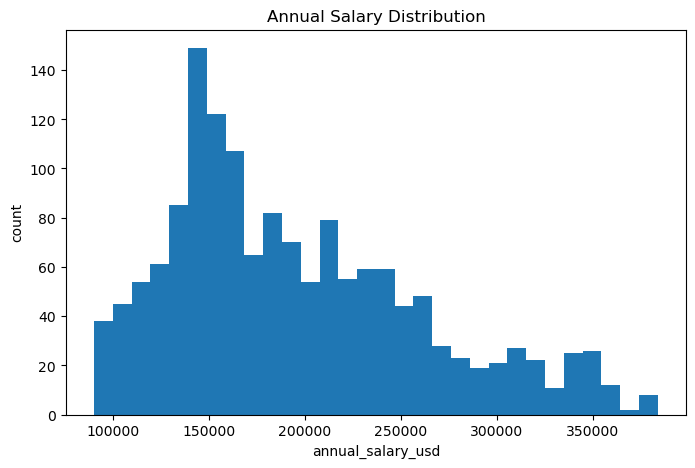

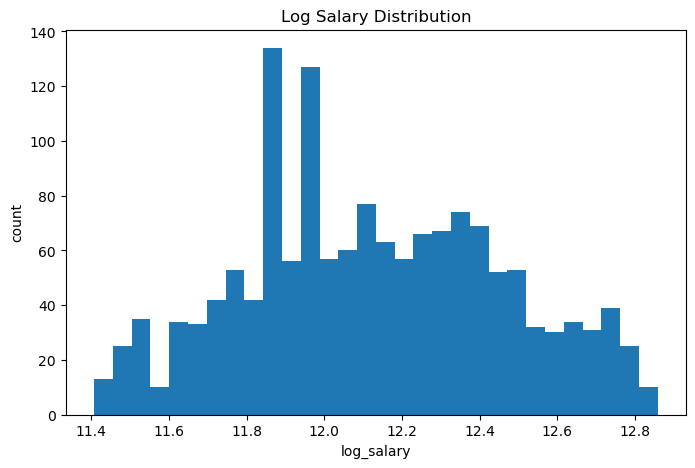

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["annual_salary_usd"], bins=30)
ax.set_title("Annual Salary Distribution")
ax.set_xlabel("annual_salary_usd")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["log_salary"], bins=30)
ax.set_title("Log Salary Distribution")
ax.set_xlabel("log_salary")
ax.set_ylabel("count")
plt.show()

## 3. Variables for regression

For the main regression, I am not using salary-derived variables like `salary_min_usd`, `salary_max_usd`, and `salary_tier`. I also avoid duplicate variables like `country`, `is_senior`, and `is_remote_friendly`.

I also leave out `ai_salary_premium_pct` for now because I am not fully sure how it was created.

In [34]:
df["is_san_francisco"] = (df["city"] == "San Francisco").astype(int)

main_vars = [
    "experience_level",
    "years_of_experience",
    "education_required",
    "job_category",
    "city",
    "remote_work",
    "company_size",
    "industry",
    "demand_score",
    "benefits_score_10",
    "is_llm_role",
]

df[main_vars + ["annual_salary_usd", "log_salary"]].head()

,experience_level,years_of_experience,education_required,job_category,city,remote_work,company_size,industry,demand_score,benefits_score_10,is_llm_role,annual_salary_usd,log_salary
0,Senior (6-9 yrs),7,Master's,AI Engineering,Boston,On-site,Startup (1-50),Finance,96,6.8,1,239000.0,12.384219
1,Senior (6-9 yrs),2,Bachelor's,AI Engineering,London,Hybrid,Enterprise (5000+),Finance,82,6.2,1,166000.0,12.019743
2,Senior (6-9 yrs),4,Associate's,AI Engineering,Seattle,Fully Remote,Big Tech (FAANG+),Finance,98,7.7,1,360000.0,12.793859
3,Senior (6-9 yrs),3,Bachelor's,Data Engineering,Singapore,Fully Remote,SME (51-500),Technology,88,9.5,0,161000.0,11.989160
4,Lead (10+ yrs),5,Bootcamp/Self-taught,Product,Los Angeles,Fully Remote,Enterprise (5000+),Automotive,85,8.9,0,283000.0,12.553202


## 4. Experience variables

Since we have both `years_of_experience` and `experience_level`, I first compare a few simple models.

In [35]:
experience_formulas = {
    "years only": "log_salary ~ years_of_experience",
    "level only": "log_salary ~ C(experience_level)",
    "both": "log_salary ~ years_of_experience + C(experience_level)"
}

experience_models = {}
for name, formula in experience_formulas.items():
    experience_models[name] = smf.ols(formula, data=df).fit()

experience_compare = pd.DataFrame({
    "model": list(experience_models.keys()),
    "r_squared": [m.rsquared for m in experience_models.values()],
    "adj_r_squared": [m.rsquared_adj for m in experience_models.values()],
    "AIC": [m.aic for m in experience_models.values()]
})

experience_compare.round(4)

,model,r_squared,adj_r_squared,AIC
0,years only,0.0087,0.0081,964.1297
1,level only,0.2758,0.2744,497.1753
2,both,0.2842,0.2823,481.7625


In [36]:
def vif_table(formula, data):
    y, X = dmatrices(formula, data, return_type="dataframe")
    X = X.drop(columns=["Intercept"], errors="ignore")

    rows = []
    for i, col in enumerate(X.columns):
        rows.append({
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i)
        })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table("log_salary ~ years_of_experience + C(experience_level)", df).round(3)

,variable,VIF
3,years_of_experience,2.710
2,C(experience_level)[T.Senior (6-9 yrs)],1.575
0,C(experience_level)[T.Lead (10+ yrs)],1.567
1,C(experience_level)[T.Mid (3-5 yrs)],1.567


For now I keep both variables in the larger model. We will decide later if one of them should be removed for a simpler final model.

## 5. Main regression models

In [37]:
baseline_formula = """
log_salary ~ C(experience_level)
           + C(education_required)
           + C(job_category)
"""

expanded_formula = """
log_salary ~ C(experience_level)
           + C(education_required)
           + C(job_category)
           + C(city)
           + C(remote_work)
           + C(company_size)
           + C(industry)
"""

final_formula = """
log_salary ~ C(experience_level)
           + years_of_experience
           + C(education_required)
           + C(job_category)
           + C(city)
           + C(remote_work)
           + C(company_size)
           + C(industry)
           + demand_score
           + benefits_score_10
           + is_llm_role
"""

baseline_model = smf.ols(baseline_formula, data=df).fit()
expanded_model = smf.ols(expanded_formula, data=df).fit()
final_model = smf.ols(final_formula, data=df).fit()

In [38]:
model_compare = pd.DataFrame({
    "model": ["baseline", "expanded", "final"],
    "r_squared": [baseline_model.rsquared, expanded_model.rsquared, final_model.rsquared],
    "adj_r_squared": [baseline_model.rsquared_adj, expanded_model.rsquared_adj, final_model.rsquared_adj],
    "AIC": [baseline_model.aic, expanded_model.aic, final_model.aic],
    "BIC": [baseline_model.bic, expanded_model.bic, final_model.bic]
})

model_compare.round(4)

,model,r_squared,adj_r_squared,AIC,BIC
0,baseline,0.4476,0.4409,120.9488,221.8999
1,expanded,0.7814,0.7732,-1197.2159,-904.9887
2,final,0.8207,0.8135,-1486.7180,-1173.2380


In [39]:
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.813
Method:                 Least Squares   F-statistic:                     113.7
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        08:37:37   Log-Likelihood:                 802.36
No. Observations:                1500   AIC:                            -1487.
Df Residuals:                    1441   BIC:                            -1173.
Df Model:                          58                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

The final model is the one I would use as the starting point for our regression section. It controls for experience, education, role, city, remote work, company size, industry, and a few job-market indicators.

## 6. Coefficient table

In [40]:
coef_table = pd.DataFrame({
    "term": final_model.params.index,
    "coef": final_model.params.values,
    "p_value": final_model.pvalues.values,
    "percent_change": (np.exp(final_model.params.values) - 1) * 100
})

coef_table = coef_table[coef_table["term"] != "Intercept"]
coef_table.sort_values("p_value").head(20).round(4)

,term,coef,p_value,percent_change
1,C(experience_level)[T.Lead (10+ yrs)],0.4666,0.0,59.4615
3,C(experience_level)[T.Senior (6-9 yrs)],0.3453,0.0,41.2474
43,C(company_size)[T.Startup (1-50)],-0.3129,0.0,-26.8673
42,C(company_size)[T.SME (51-500)],-0.2622,0.0,-23.0618
41,C(company_size)[T.Mid-size (501-5000)],-0.2154,0.0,-19.3796
56,demand_score,0.0184,0.0,1.8563
7,C(education_required)[T.PhD],0.1877,0.0,20.6505
31,C(city)[T.San Francisco],0.3320,0.0,39.3822
2,C(experience_level)[T.Mid (3-5 yrs)],0.1559,0.0,16.8655
8,C(job_category)[T.Architecture],0.3322,0.0,39.4084


I mainly look at the coefficient direction and the p-value here. Since the outcome is log salary, the percent change column is easier to read than the raw coefficient.

## 7. VIF check

In [41]:
def fast_vif_table(formula, data):
    y, X = dmatrices(formula, data, return_type="dataframe")
    X = X.drop(columns=["Intercept"], errors="ignore")
    X = X.loc[:, X.std(axis=0) > 0]

    Z = (X - X.mean(axis=0)) / X.std(axis=0, ddof=0)
    corr = np.corrcoef(Z.values, rowvar=False)
    inv_corr = np.linalg.pinv(corr)

    return pd.DataFrame({
        "variable": X.columns,
        "VIF": np.diag(inv_corr)
    }).sort_values("VIF", ascending=False)

final_vif = fast_vif_table(final_formula, df)
final_vif.head(20).round(3)

,variable,VIF
55,demand_score,6.035
11,C(job_category)[T.Governance],4.823
16,C(job_category)[T.Robotics],2.301
30,C(city)[T.San Francisco],2.154
25,C(city)[T.London],2.113
20,C(city)[T.Beijing],2.106
35,C(city)[T.Toronto],2.080
21,C(city)[T.Berlin],2.035
29,C(city)[T.Remote],2.033
33,C(city)[T.Sydney],1.998


In [42]:
final_vif[final_vif["VIF"] > 5].round(3)

,variable,VIF
55,demand_score,6.035


This is a quick check for multicollinearity. Some dummy variables may have higher VIF, so I would not automatically remove them without checking the model logic.

## 8. Basic regression diagnostics

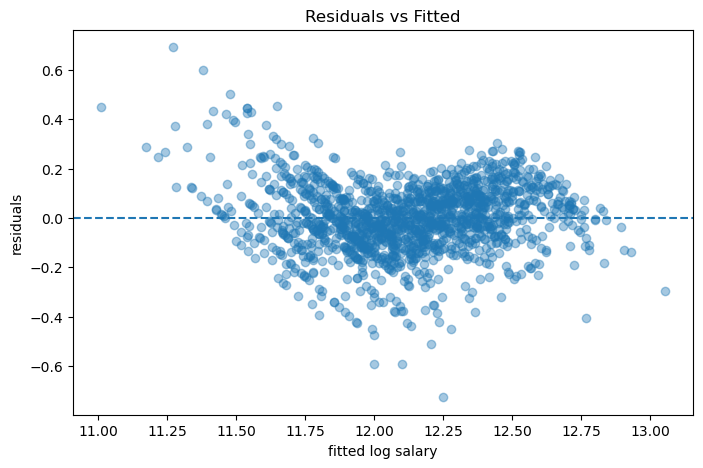

In [43]:
residuals = final_model.resid
fitted = final_model.fittedvalues

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fitted, residuals, alpha=0.4)
ax.axhline(0, linestyle="--")
ax.set_xlabel("fitted log salary")
ax.set_ylabel("residuals")
ax.set_title("Residuals vs Fitted")
plt.show()

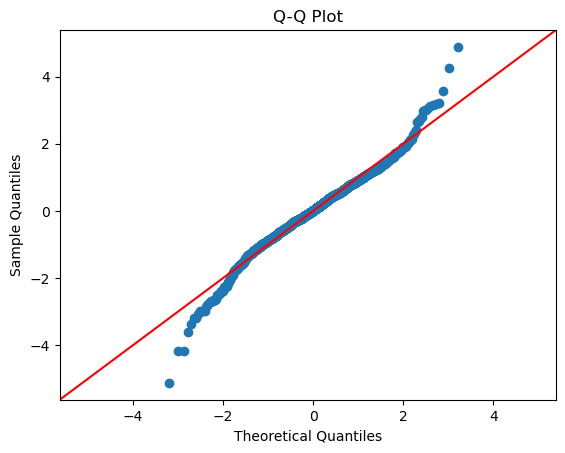

In [44]:
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot")
plt.show()

In [45]:
shapiro_stat, shapiro_p = stats.shapiro(residuals)
bp_stat, bp_p, _, _ = het_breuschpagan(residuals, final_model.model.exog)
dw_stat = durbin_watson(residuals)

diagnostics = pd.DataFrame({
    "check": ["Shapiro-Wilk", "Breusch-Pagan", "Durbin-Watson"],
    "statistic": [shapiro_stat, bp_stat, dw_stat],
    "p_value": [shapiro_p, bp_p, np.nan]
})

diagnostics

,check,statistic,p_value
0,Shapiro-Wilk,0.980878,3.104763e-13
1,Breusch-Pagan,383.396229,1.753284e-49
2,Durbin-Watson,2.024883,NaN


These checks are not meant to make the model perfect. They just show whether there are obvious issues we should mention in the report.

## 9. Cook's distance

In [46]:
influence = final_model.get_influence()
cooks_distance = influence.cooks_distance[0]
cook_threshold = 4 / len(df)

cook_summary = pd.DataFrame({
    "row_index": df.index,
    "job_id": df["job_id"],
    "annual_salary_usd": df["annual_salary_usd"],
    "city": df["city"],
    "job_category": df["job_category"],
    "cooks_distance": cooks_distance
})

print("threshold:", cook_threshold)
print("rows above threshold:", (cook_summary["cooks_distance"] > cook_threshold).sum())

cook_summary.sort_values("cooks_distance", ascending=False).head(10)

threshold: 0.0026666666666666666
rows above threshold: 73


,row_index,job_id,annual_salary_usd,city,job_category,cooks_distance
1268,1268,AIJOB1269,157000.0,Beijing,Data Science,0.014805
407,407,AIJOB0408,101000.0,Beijing,AI Engineering,0.013362
242,242,AIJOB0243,160000.0,Bangalore,AI Engineering,0.011957
221,221,AIJOB0222,90000.0,Beijing,AI Engineering,0.010905
1067,1067,AIJOB1068,120000.0,Bangalore,AI Engineering,0.009030
919,919,AIJOB0920,100000.0,Beijing,AI Engineering,0.008665
1448,1448,AIJOB1449,101000.0,Beijing,AI Engineering,0.008213
1350,1350,AIJOB1351,140000.0,Bangalore,Product,0.007770
145,145,AIJOB0146,157000.0,Bangalore,Data Science,0.007770
1094,1094,AIJOB1095,95000.0,Beijing,Business,0.007522


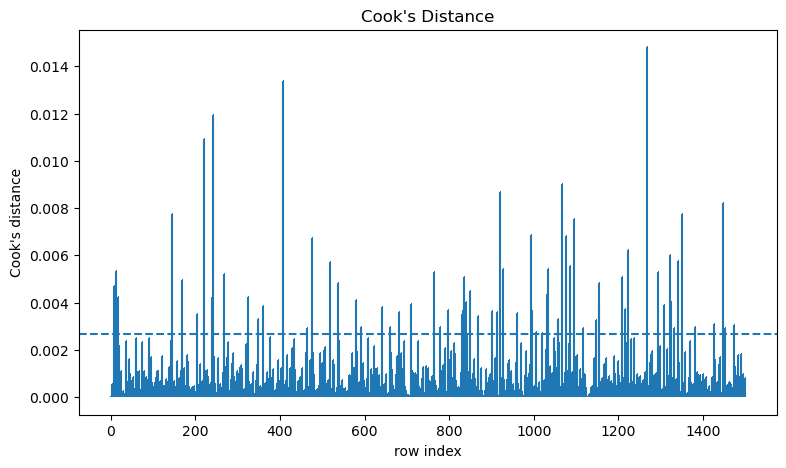

In [47]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.stem(df.index, cooks_distance, markerfmt=",", basefmt=" ")
ax.axhline(cook_threshold, linestyle="--")
ax.set_xlabel("row index")
ax.set_ylabel("Cook's distance")
ax.set_title("Cook's Distance")
plt.show()

I do not remove any rows here. Sunny is already checking outliers/influential points, so this can connect to her part later.

## 10. Interaction model

In [48]:
interaction_formula = """
log_salary ~ years_of_experience * C(remote_work)
           + C(experience_level)
           + C(education_required)
           + C(job_category)
           + C(city)
           + C(company_size)
           + C(industry)
           + demand_score
           + benefits_score_10
           + is_llm_role
"""

interaction_model = smf.ols(interaction_formula, data=df).fit()

pd.DataFrame({
    "model": ["final", "remote interaction"],
    "adj_r_squared": [final_model.rsquared_adj, interaction_model.rsquared_adj],
    "AIC": [final_model.aic, interaction_model.aic]
}).round(4)

,model,adj_r_squared,AIC
0,final,0.8135,-1486.7180
1,remote interaction,0.8136,-1486.1931


In [49]:
interaction_terms = pd.DataFrame({
    "term": interaction_model.params.index,
    "coef": interaction_model.params.values,
    "p_value": interaction_model.pvalues.values
})

interaction_terms[interaction_terms["term"].str.contains("years_of_experience:C\\(remote_work\\)", regex=True)].round(4)

,term,coef,p_value
56,years_of_experience:C(remote_work)[T.Hybrid],0.0019,0.5811
57,years_of_experience:C(remote_work)[T.On-site],0.0068,0.0778


In [50]:
sf_formula = """
log_salary ~ years_of_experience * is_san_francisco
           + C(experience_level)
           + C(education_required)
           + C(job_category)
           + C(remote_work)
           + C(company_size)
           + C(industry)
           + demand_score
           + benefits_score_10
           + is_llm_role
"""

sf_model = smf.ols(sf_formula, data=df).fit()

sf_terms = pd.DataFrame({
    "term": sf_model.params.index,
    "coef": sf_model.params.values,
    "p_value": sf_model.pvalues.values
})

sf_terms[sf_terms["term"].str.contains("years_of_experience|is_san_francisco", regex=True)].round(4)

,term,coef,p_value
36,years_of_experience,0.0082,0.0005
37,is_san_francisco,0.2897,0.0000
38,years_of_experience:is_san_francisco,-0.0001,0.9863


I tried two interaction ideas: experience by remote work, and experience by San Francisco. We can decide which one is more useful for the final report after looking at the p-values and whether the model fit improves.

## 11. Things to discuss later

- Whether the final model should keep both `years_of_experience` and `experience_level`
- Whether we want full `city` controls or a simpler city variable
- Which interaction model is easiest to explain in the report
- How to connect Cook's distance with Sunny's outlier section